In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('../outputs/featured_data.csv')


In [2]:
item_sales = df.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)
total_sales = item_sales.sum()

cumulative_pct = (item_sales.cumsum() / total_sales * 100)

print("Item Type Sales (sorted):")
print(item_sales)
print("\nCumulative %:")
print(cumulative_pct)

Item Type Sales (sorted):
Item_Type
Fruits and Vegetables    2.820060e+06
Snack Foods              2.732786e+06
Household                2.055494e+06
Frozen Foods             1.825735e+06
Dairy                    1.522594e+06
Canned                   1.444151e+06
Baking Goods             1.265525e+06
Health and Hygiene       1.045200e+06
Meat                     9.175656e+05
Soft Drinks              8.928977e+05
Breads                   5.532372e+05
Hard Drinks              4.577934e+05
Starchy Foods            3.514013e+05
Others                   3.255176e+05
Breakfast                2.322990e+05
Seafood                  1.488682e+05
Name: Item_Outlet_Sales, dtype: float64

Cumulative %:
Item_Type
Fruits and Vegetables     15.168849
Snack Foods               29.868261
Household                 40.924578
Frozen Foods              50.745042
Dairy                     58.934939
Canned                    66.702901
Baking Goods              73.510048
Health and Hygiene        79.132086
Mea

In [3]:
top_items = cumulative_pct[cumulative_pct <= 80]
print(f"\nTop {len(top_items)} item types account for 80% of sales")


Top 8 item types account for 80% of sales


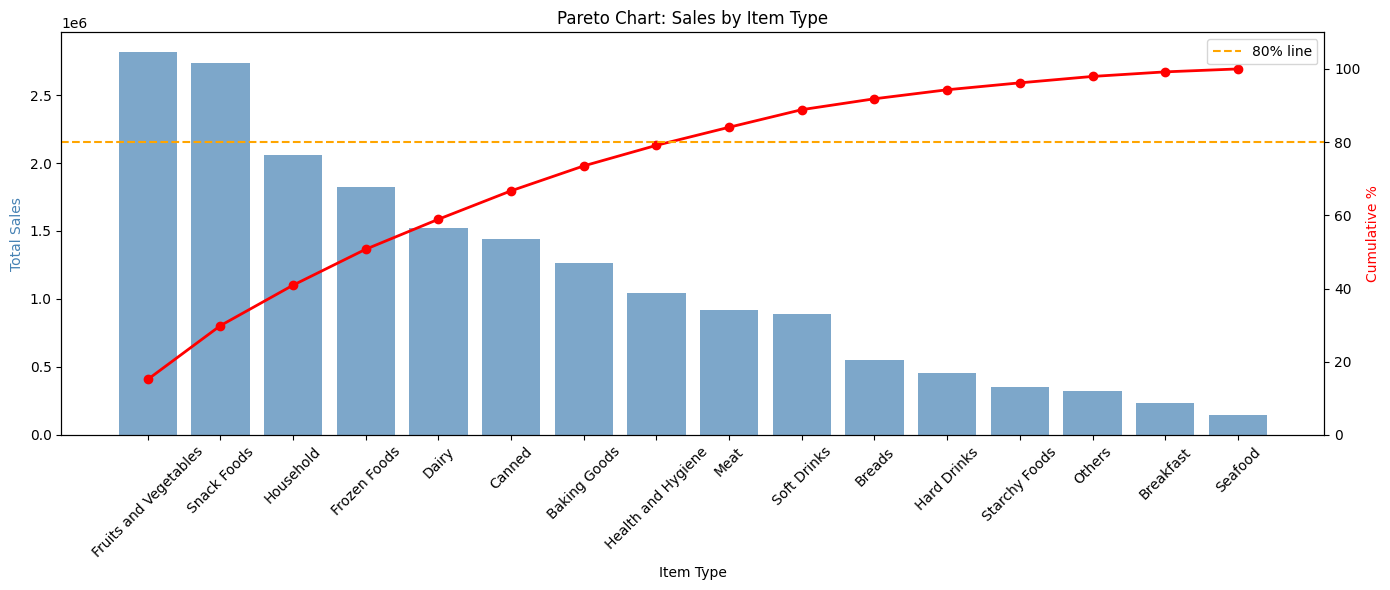

In [4]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(item_sales.index, item_sales.values, color='steelblue', alpha=0.7)
ax1.set_xlabel('Item Type')
ax1.set_ylabel('Total Sales', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(item_sales.index, cumulative_pct.values, color='red', marker='o', linewidth=2)
ax2.axhline(80, color='orange', linestyle='--', label='80% line')
ax2.set_ylabel('Cumulative %', color='red')
ax2.set_ylim(0, 110)
ax2.legend()

plt.title('Pareto Chart: Sales by Item Type')
plt.tight_layout()
plt.savefig('../outputs/pareto_chart.png', dpi=150)
plt.show()

In [5]:
tier2_sales = df[df['Outlet_Location_Type'] == 'Tier 2']['Item_Outlet_Sales']
tier3_sales = df[df['Outlet_Location_Type'] == 'Tier 3']['Item_Outlet_Sales']

print(f"Tier 2 — Mean: {tier2_sales.mean():.2f}, Count: {len(tier2_sales)}")
print(f"Tier 3 — Mean: {tier3_sales.mean():.2f}, Count: {len(tier3_sales)}")

Tier 2 — Mean: 2323.99, Count: 2785
Tier 3 — Mean: 2279.63, Count: 3350


In [6]:
t_stat, p_value = stats.ttest_ind(tier2_sales, tier3_sales)

print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ Result: SIGNIFICANT difference between Tier 2 and Tier 3 sales (p < 0.05)")
    print("   → Tier 2 and Tier 3 outlets ARE competitively different.")
else:
    print("❌ Result: NO significant difference (p >= 0.05)")


t-statistic: 0.9911
p-value: 0.3217
❌ Result: NO significant difference (p >= 0.05)


/var/folders/cc/75b1ky1508z3814t00pdgrh00000gp/T/ipykernel_3602/845880487.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([tier2_sales, tier3_sales], labels=['Tier 2', 'Tier 3'])


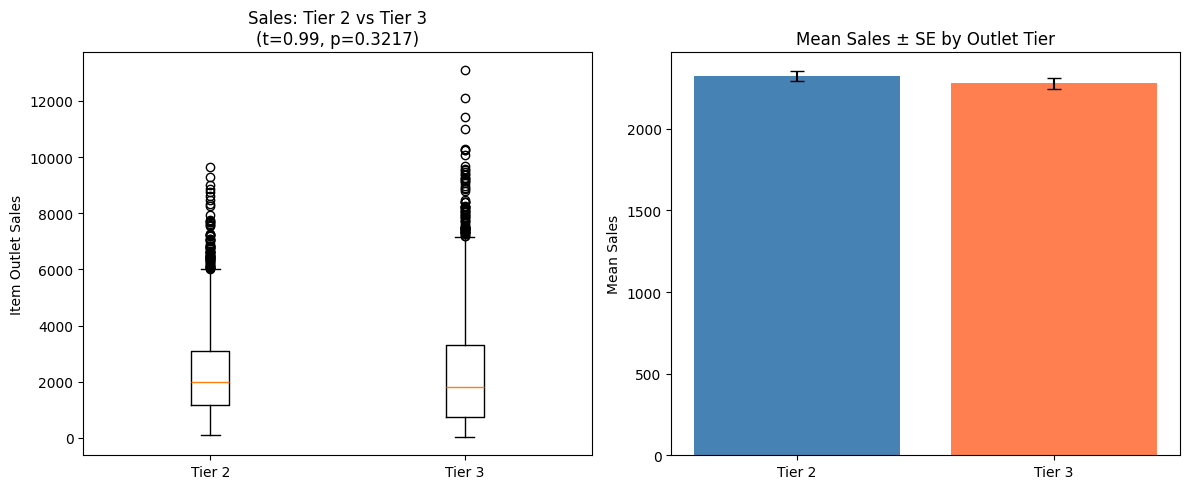

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
axes[0].boxplot([tier2_sales, tier3_sales], labels=['Tier 2', 'Tier 3'])
axes[0].set_title(f'Sales: Tier 2 vs Tier 3\n(t={t_stat:.2f}, p={p_value:.4f})')
axes[0].set_ylabel('Item Outlet Sales')

# Bar with error bars
means = [tier2_sales.mean(), tier3_sales.mean()]
sems = [tier2_sales.sem(), tier3_sales.sem()]
axes[1].bar(['Tier 2', 'Tier 3'], means, yerr=sems, capsize=5, color=['steelblue', 'coral'])
axes[1].set_title('Mean Sales ± SE by Outlet Tier')
axes[1].set_ylabel('Mean Sales')

plt.tight_layout()
plt.savefig('../outputs/tier_comparison.png', dpi=150)
plt.show()

In [8]:
low_fat_sales = df[df['Item_Fat_Content'] == 'Low Fat']['Item_Outlet_Sales']
regular_sales = df[df['Item_Fat_Content'] == 'Regular']['Item_Outlet_Sales']

t2, p2 = stats.ttest_ind(low_fat_sales, regular_sales)
print(f"\nLow Fat vs Regular Items:")
print(f"Low Fat Mean: {low_fat_sales.mean():.2f} | Regular Mean: {regular_sales.mean():.2f}")
print(f"t={t2:.4f}, p={p2:.4f} → {'Significant' if p2 < 0.05 else 'Not Significant'}")


Low Fat vs Regular Items:
Low Fat Mean: 2157.71 | Regular Mean: 2224.56
t=-1.7282, p=0.0840 → Not Significant


In [9]:
stats_summary = pd.DataFrame({
    'Test': ['Pareto: Items covering 80% sales', 'T-Test: Tier2 vs Tier3', 'T-Test: Low Fat vs Regular'],
    'Result': [
        f"Top {len(top_items)} of 16 item types = 80% of revenue",
        f"t={t_stat:.4f}, p={p_value:.4f} ({'Significant' if p_value < 0.05 else 'Not Significant'})",
        f"t={t2:.4f}, p={p2:.4f} ({'Significant' if p2 < 0.05 else 'Not Significant'})"
    ]
})
stats_summary.to_csv('../outputs/statistical_results.csv', index=False)
print(stats_summary)

                               Test                                   Result
0  Pareto: Items covering 80% sales  Top 8 of 16 item types = 80% of revenue
1            T-Test: Tier2 vs Tier3     t=0.9911, p=0.3217 (Not Significant)
2        T-Test: Low Fat vs Regular    t=-1.7282, p=0.0840 (Not Significant)
